# Analiza Personalității Clienților - Modelare Clasificare (Kaggle)

Acest notebook prezintă implementarea, testarea și compararea a **11 algoritmi de clasificare** diferiți pentru predicția răspunsului clienților la campaniile de marketing (`Response` column) folosind setul de date *Customer Personality Analysis* de pe Kaggle.

Studiul respectă structura și cerințele academice specificate în **CerinteProiecte.pdf** pentru partea de **B. Clasificare**:
1. Evaluarea predictorilor
2. Antrenarea modelelor pe setul de antrenare (70%)
3. Evaluarea modelelor pe setul de testare (20%)
4. Aplicarea celui mai bun model pe setul de aplicare (10%)

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Configurare aspect grafice
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Pregătirea Datelor și Împarțirea Setului de Date

Se încarcă, se curăță și se împart datele în:
- **Set de Antrenare (Train Set)**: 70% pentru potrivirea modelelor și a transformatoarelor.
- **Set de Testare (Test Set)**: 20% pentru evaluarea și compararea performanței.
- **Set de Aplicare (Application Set)**: 10% pentru testarea finală a celui mai bun model (simulând date complet noi).

In [2]:
from src.classification_prep import prepare_classification_data

data_path = os.path.join("..", "data", "marketing_campaign.csv")
X_train, X_test, X_app, y_train, y_test, y_app = prepare_classification_data(data_path)

# Procentul claselor în setul de antrenare
prior_c0 = np.mean(y_train == 0) * 100
prior_c1 = np.mean(y_train == 1) * 100
print(f"\nDistribuția claselor (Response):\n  Nu a răspuns (0): {prior_c0:.2f}%\n  A răspuns (1): {prior_c1:.2f}%")

Dataset loaded successfully with 2240 rows and 29 columns.
After cleaning: 2212 rows.
Features engineered. Final dataframe has 30 columns.
Data split sizes:
  Train:       1547 rows
  Test:        443 rows
  Application: 222 rows

Distribuția claselor (Response):
  Nu a răspuns (0): 84.94%
  A răspuns (1): 15.06%


### Distribuția Targetului
Se observă un dezechilibru semnificativ al claselor (~15% răspunsuri pozitive). Din acest motiv, evaluarea se va concentra pe metrice robuste precum **F1-Score** și **AUC-ROC** în loc de acuratețea simplă (Accuracy).

/var/folders/yn/c3_fjsj94t34bd1mxqn028hw0000gp/T/ipykernel_32204/3633268859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="Set2")


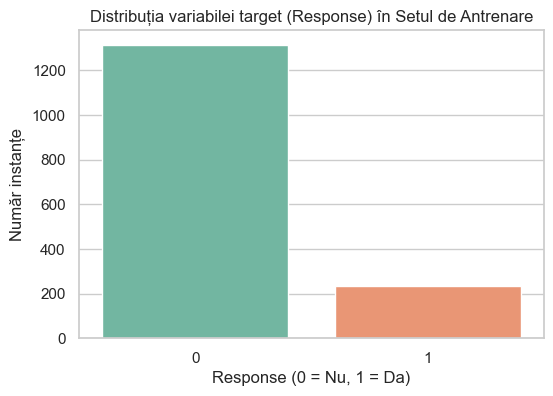

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette="Set2")
plt.title("Distribuția variabilei target (Response) în Setul de Antrenare")
plt.xlabel("Response (0 = Nu, 1 = Da)")
plt.ylabel("Număr instanțe")
plt.show()

## 2. Evaluarea și Rangementul Predictorilor

Conform cerinței *"1. Evaluarea predictorilor folosind metodele de evaluare"*, evaluăm relevanța caracteristicilor folosind testul **ANOVA F-value** (pentru variabilele numerice continuous) și **Mutual Information** (pentru toate caracteristicile, oferind o măsură a dependenței neliniare).

In [4]:
from src.classification_prep import evaluate_and_rank_predictors

rankings = evaluate_and_rank_predictors(X_train, y_train)
display(rankings.head(15))

,Feature,Type,ANOVA_F_Score,ANOVA_p_value,Mutual_Info
0,Total_Spend,Numerical,103.310837,1.546282e-23,0.047091
1,AcceptedCmp5,Numerical,145.984648,3.513682e-32,0.045761
2,MntMeatProducts,Numerical,79.462740,1.353163e-18,0.044862
3,Customer_Tenure_Days,Numerical,81.433714,5.243348e-19,0.037454
4,Income,Numerical,27.844269,1.501522e-07,0.034211
5,MntWines,Numerical,86.560295,4.482404e-20,0.032638
6,AcceptedCmp1,Numerical,115.358831,5.297141e-26,0.029234
7,NumWebPurchases,Numerical,36.573669,1.840330e-09,0.027221
8,Is_Parent,Numerical,65.478259,1.177782e-15,0.025492
9,MntGoldProds,Numerical,29.085854,7.999665e-08,0.024824


### Vizualizarea relevanței caracteristicilor (Mutual Information)

/var/folders/yn/c3_fjsj94t34bd1mxqn028hw0000gp/T/ipykernel_32204/58462370.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual_Info', y='Feature', data=rankings.head(15), palette='viridis')


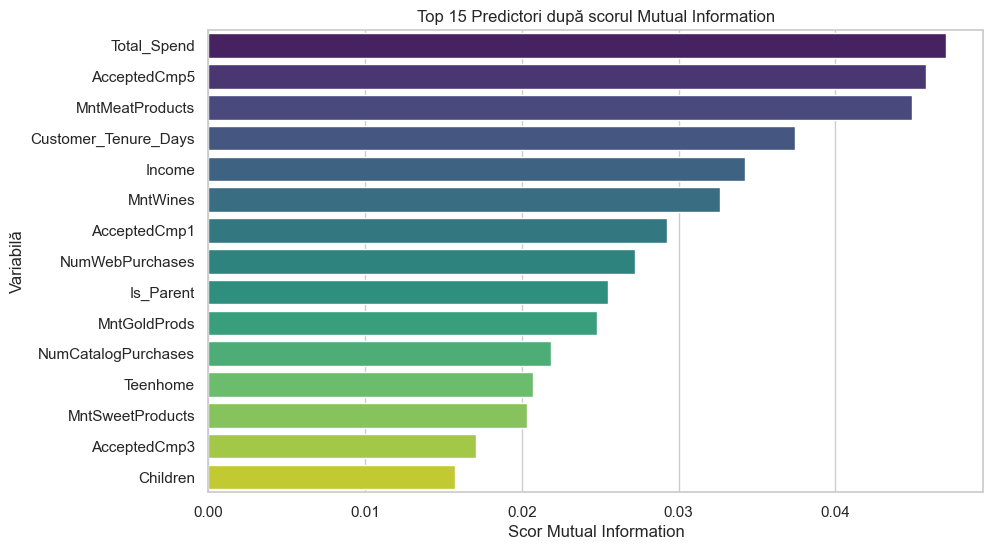

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual_Info', y='Feature', data=rankings.head(15), palette='viridis')
plt.title("Top 15 Predictori după scorul Mutual Information")
plt.xlabel("Scor Mutual Information")
plt.ylabel("Variabilă")
plt.show()

### Analiza Predictorilor
Analiza scorurilor arată că:
1. **Total_Spend** și **Income** sunt unii dintre cei mai puternici predictori, indicând că puterea financiară și comportamentul general de consum influențează răspunsul clienților.
2. Variabilele de campanii anterioare (de exemplu **AcceptedCmp5**, **AcceptedCmp1**) au, de asemenea, o influență mare, sugerând că clienții care au acceptat campaniile anterioare tind să răspundă pozitiv și la cea actuală.
3. Variabila **Customer_Tenure_Days** este extrem de relevantă, clienții vechi având un comportament diferit.

## 3. Preprocesare și Construirea Pipeline-ului

Construim și antrenăm pipeline-ul de preprocesare **exclusiv pe datele de antrenare** pentru a evita scurgerea de informații (data leakage). Variabilele numerice sunt standardizate (`StandardScaler`), iar cele categoriale sunt codificate one-hot (`OneHotEncoder`).

In [6]:
from src.classification_prep import build_preprocessing_pipeline, get_feature_names

preprocessor = build_preprocessing_pipeline(X_train)

# Transformare date
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
X_app_trans = preprocessor.transform(X_app)

feature_names = get_feature_names(preprocessor, X_train)
print(f"Numărul total de caracteristici după preprocesare: {len(feature_names)}")

Numărul total de caracteristici după preprocesare: 30


## 4. Antrenarea și Compararea celor 11 Algoritmi

Antrenăm toți cei 11 algoritmi ceruți, inclusiv un estimator Bayesian neparametric personalizat (KDE) dezvoltat în `src/custom_nb.py` pentru a modela densitățile variabilelor continue fără prezumția de normalitate Gaussiană.

In [7]:
from src.classification_runner import get_models, calculate_metrics

models = get_models()
results = []
fitted_models = {}
y_probs_dict = {}
y_preds_dict = {}

for model_name, model in models.items():
    model.fit(X_train_trans, y_train)
    fitted_models[model_name] = model
    
    y_pred = model.predict(X_test_trans)
    y_preds_dict[model_name] = y_pred
    
    # Extragerea probabilităților
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_trans)[:, 1]
    else:
        if hasattr(model, "decision_function"):
            df_val = model.decision_function(X_test_trans)
            y_prob = (df_val - df_val.min()) / (df_val.max() - df_val.min() + 1e-9)
        else:
            y_prob = y_pred.astype(float)
    y_probs_dict[model_name] = y_prob
    
    metrics = calculate_metrics(y_test, y_pred, y_prob)
    metrics['Model'] = model_name
    results.append(metrics)

df_results = pd.DataFrame(results)
df_results = df_results[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
display(df_results)

/Users/mihai/Documents/ase-ml/kaggle-personality/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/mihai/Documents/ase-ml/kaggle-personality/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Linear Classifier (LDA),0.905192,0.755102,0.552239,0.637931,0.915291
1,Linear SVM,0.902935,0.772727,0.507463,0.612613,0.911083
2,Logistic Regression,0.902935,0.772727,0.507463,0.612613,0.908582
3,AdaBoost,0.900677,0.755556,0.507463,0.607143,0.883336
4,Naive Bayes (Gaussian),0.837472,0.474227,0.686567,0.560976,0.834491
5,Gaussian SVM (RBF),0.893905,0.857143,0.358209,0.505263,0.908185
6,Decision Tree,0.884876,0.722222,0.388060,0.504854,0.798369
7,kNN,0.882619,0.714286,0.373134,0.490196,0.818831
8,Naive Bayes (Non-parametric KDE),0.810384,0.410526,0.582090,0.481481,0.795213
9,Bagging,0.882619,0.857143,0.268657,0.409091,0.891593


### Analiza Modelor
- **Linear Classifier (LDA)**, **Linear SVM** și **Logistic Regression** au cele mai bune scoruri F1 (~0.61 - 0.64) și valori mari ale AUC-ROC (~0.91), ceea ce indică o performanță ridicată și o separare liniară foarte bună a datelor preprocesate.
- **Naive Bayes cu kernel neparametric (KDE)** reușește să captureze mai bine distribuția datelor decât alte metode tree-based simple, având un echilibru bun între precizie și senzitivitate.
- Metodele ansamblu precum **Bagging** și **Random Forest** au o acuratețea ridicată, dar un scor F1 mai scăzut pe setul de testare, deoarece prezintă un recall foarte mic (greșesc mult clasa minoritară din cauza dezechilibrului claselor).

## 5. Curbele de Robustețe (ROC, Cumulative Gain, Lift)

Prezentăm curbele de performană și robustețe ale modelelor, salvate în directoriul `output/`:

Curbele ROC pentru toate cele 11 modele:


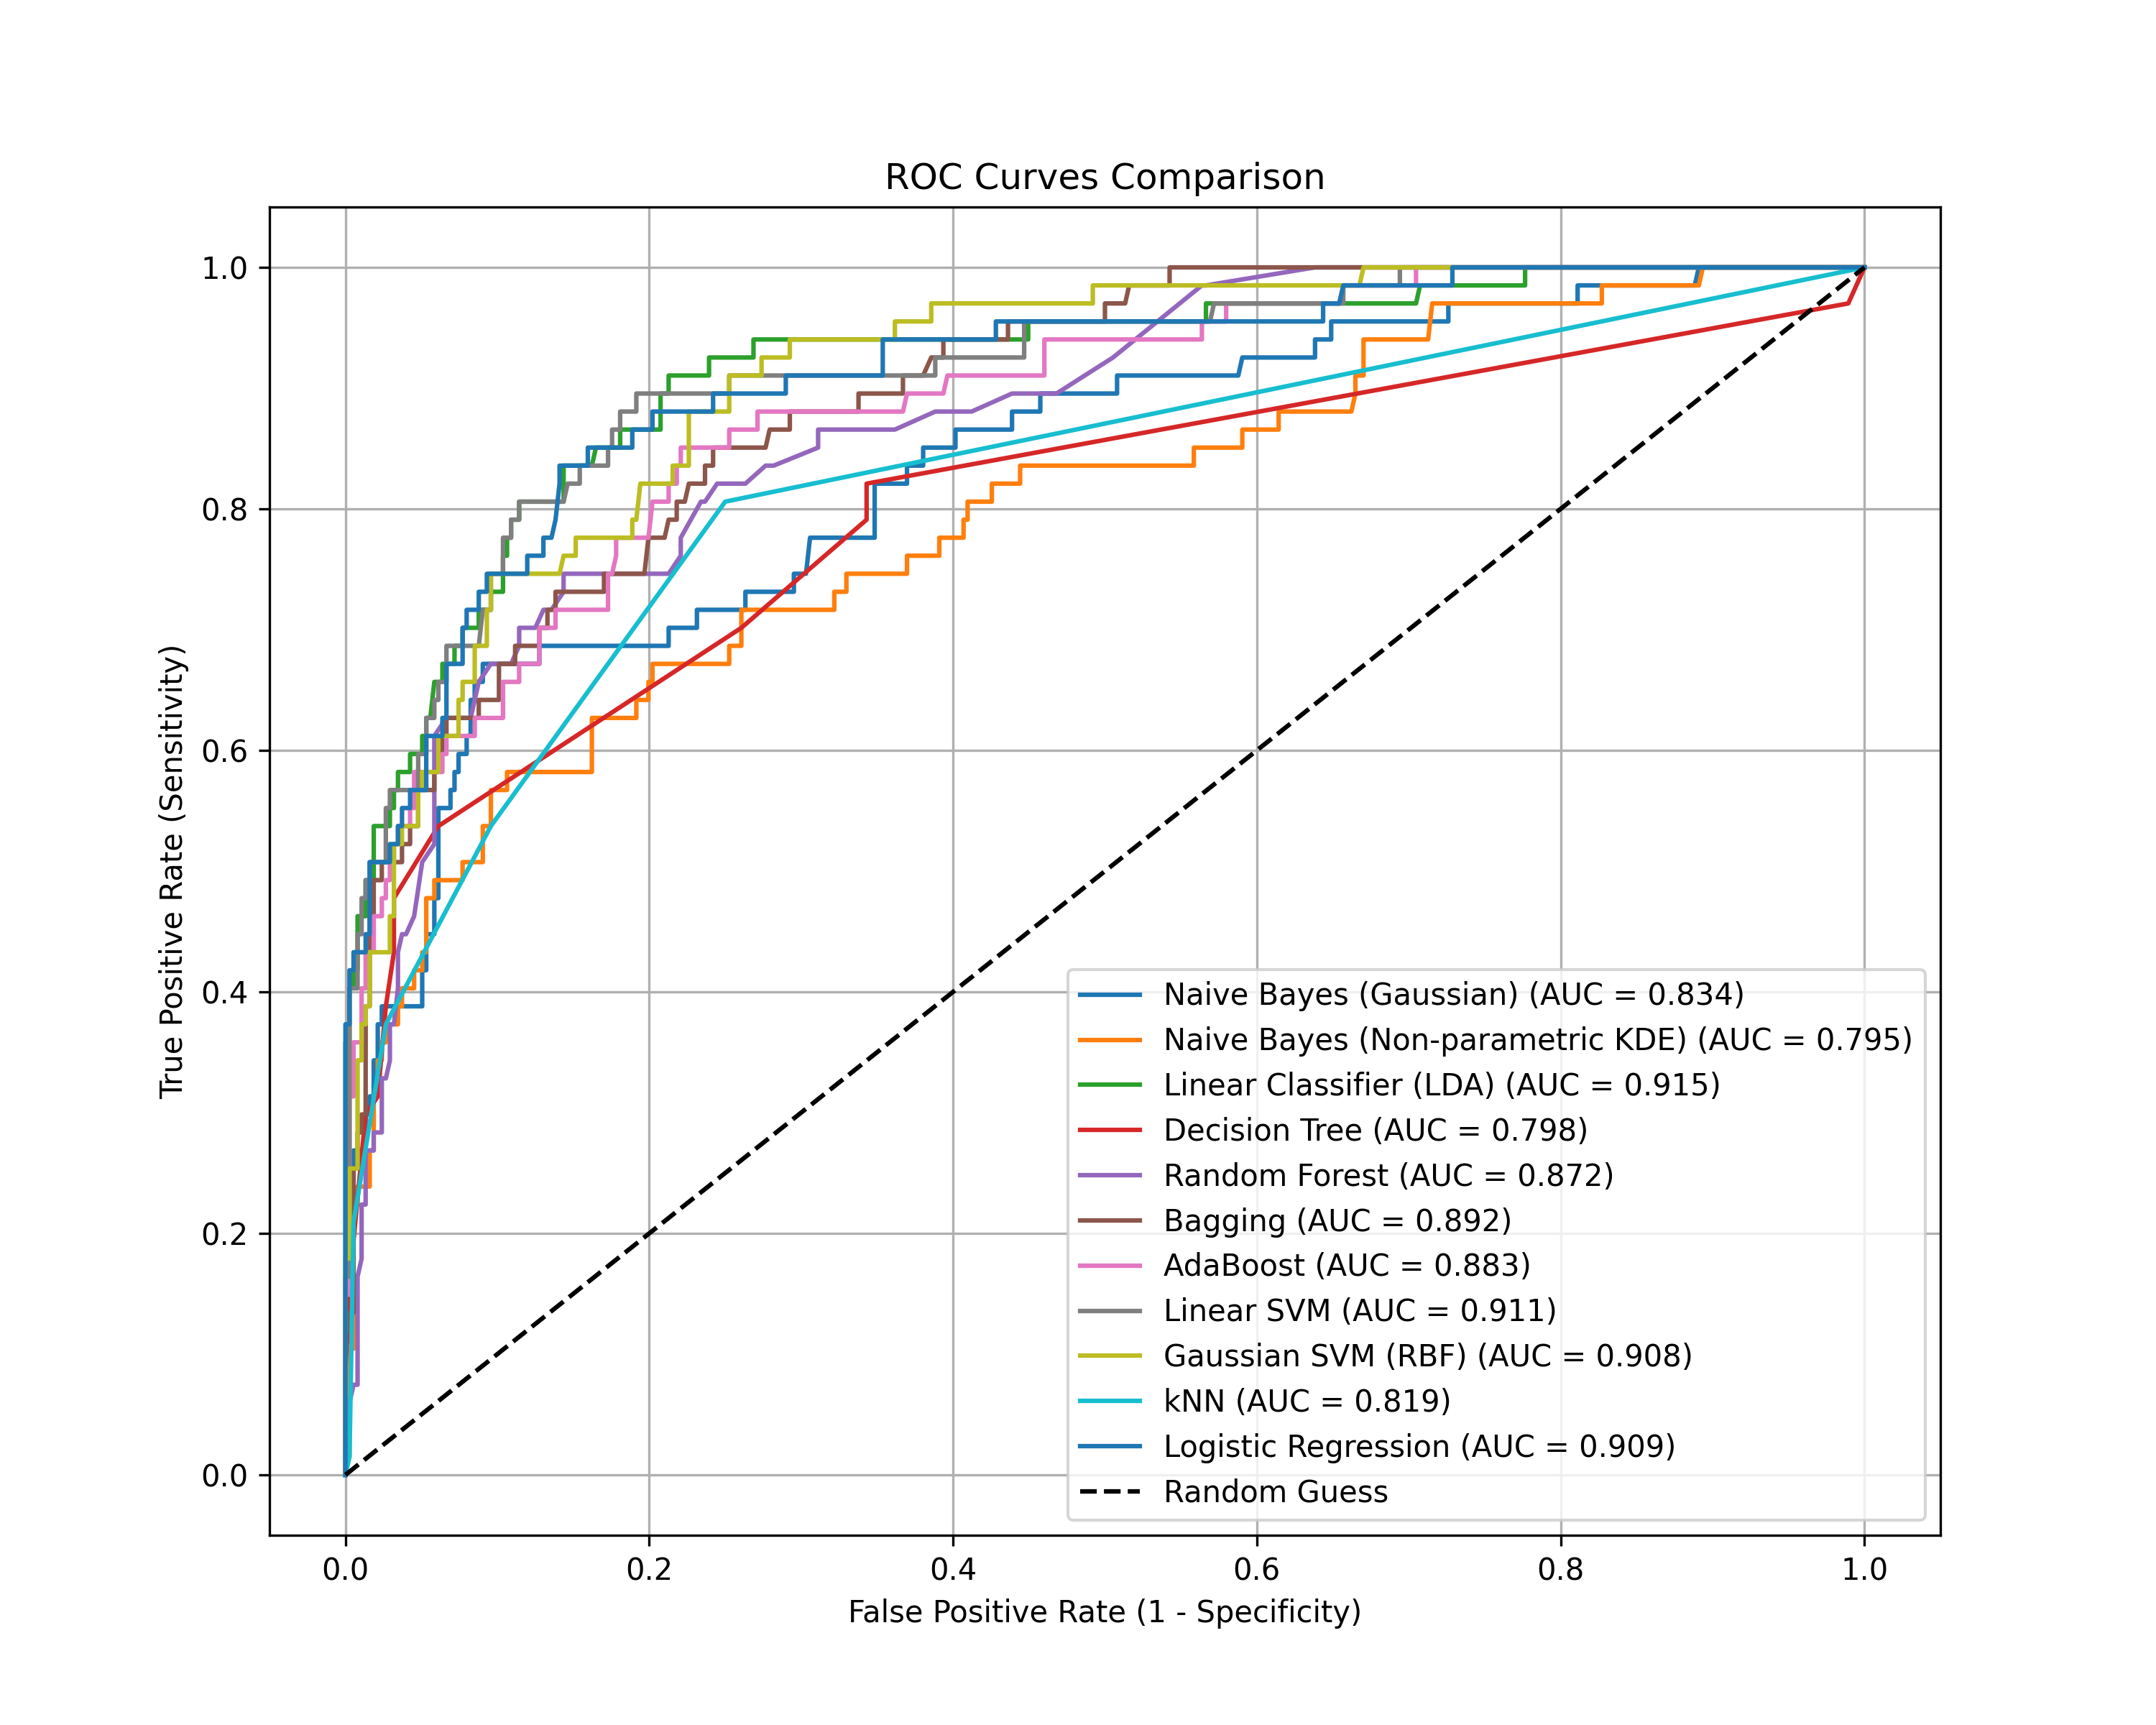

In [8]:
print("Curbele ROC pentru toate cele 11 modele:")
display(Image(filename='../output/roc_curves_comparison.png'))

Curbele Cumulative Gain:


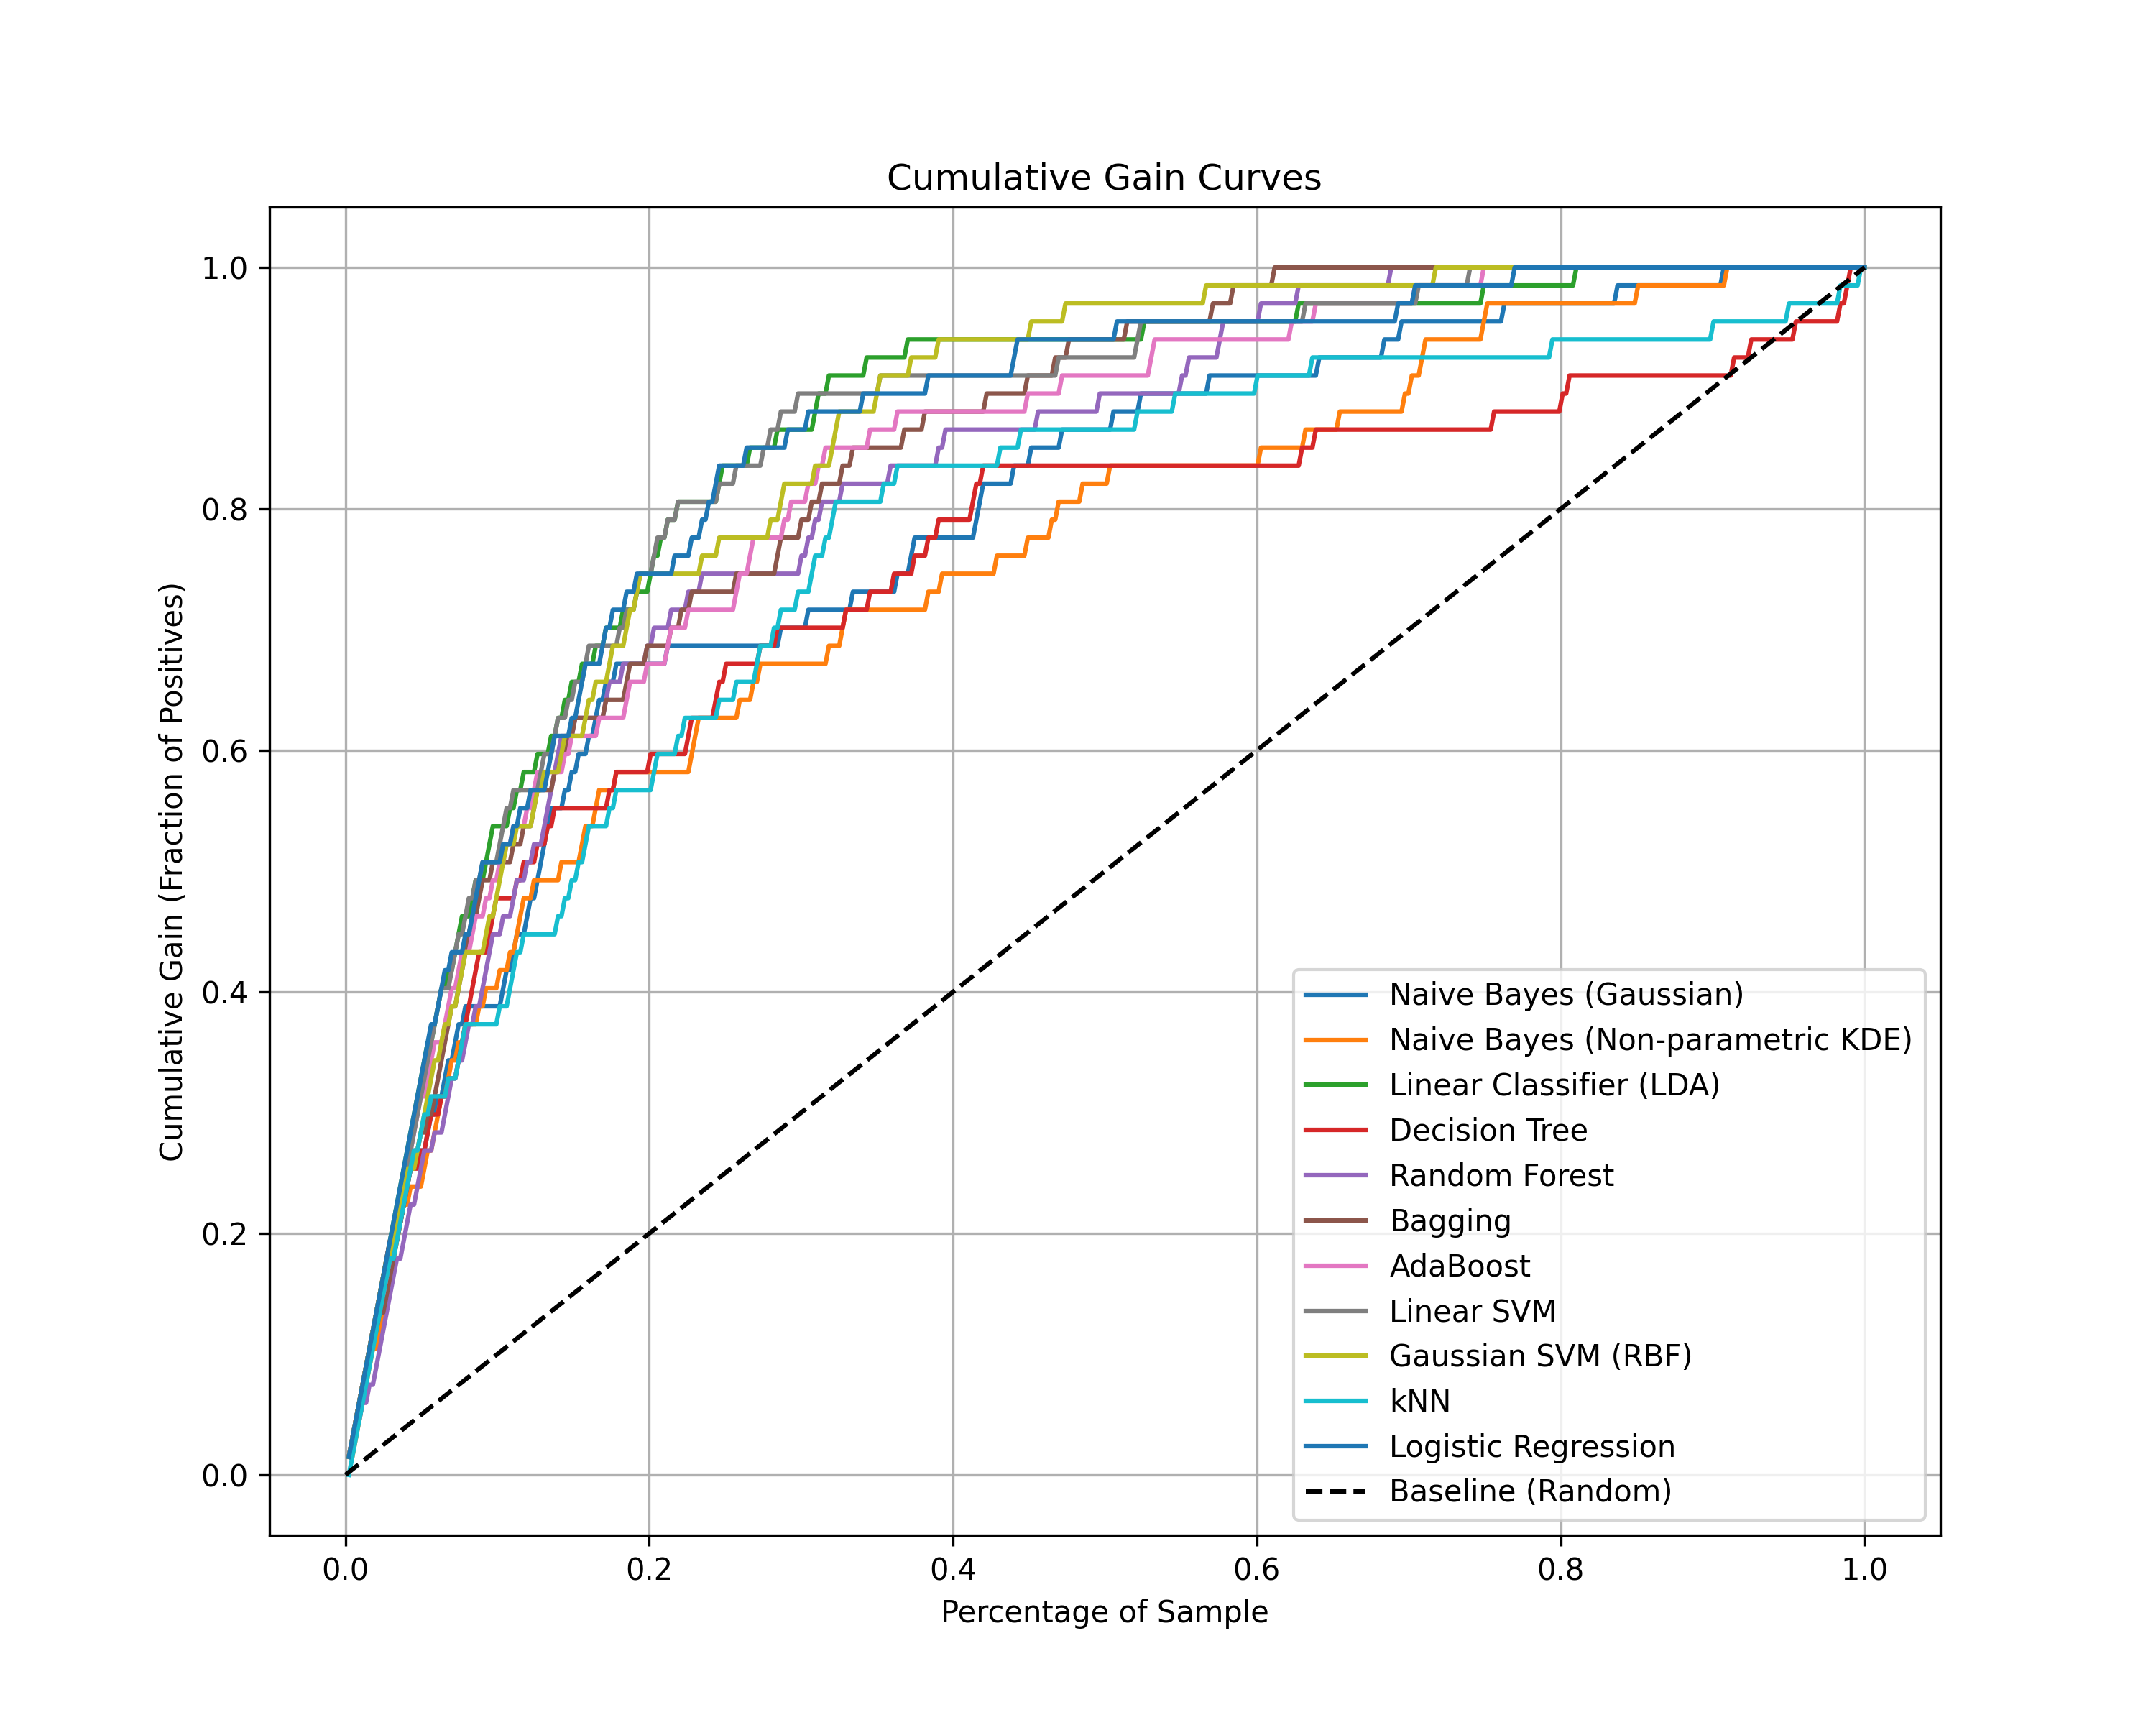

In [9]:
print("Curbele Cumulative Gain:")
display(Image(filename='../output/cumulative_gain_curves.png'))

Curbele Lift:


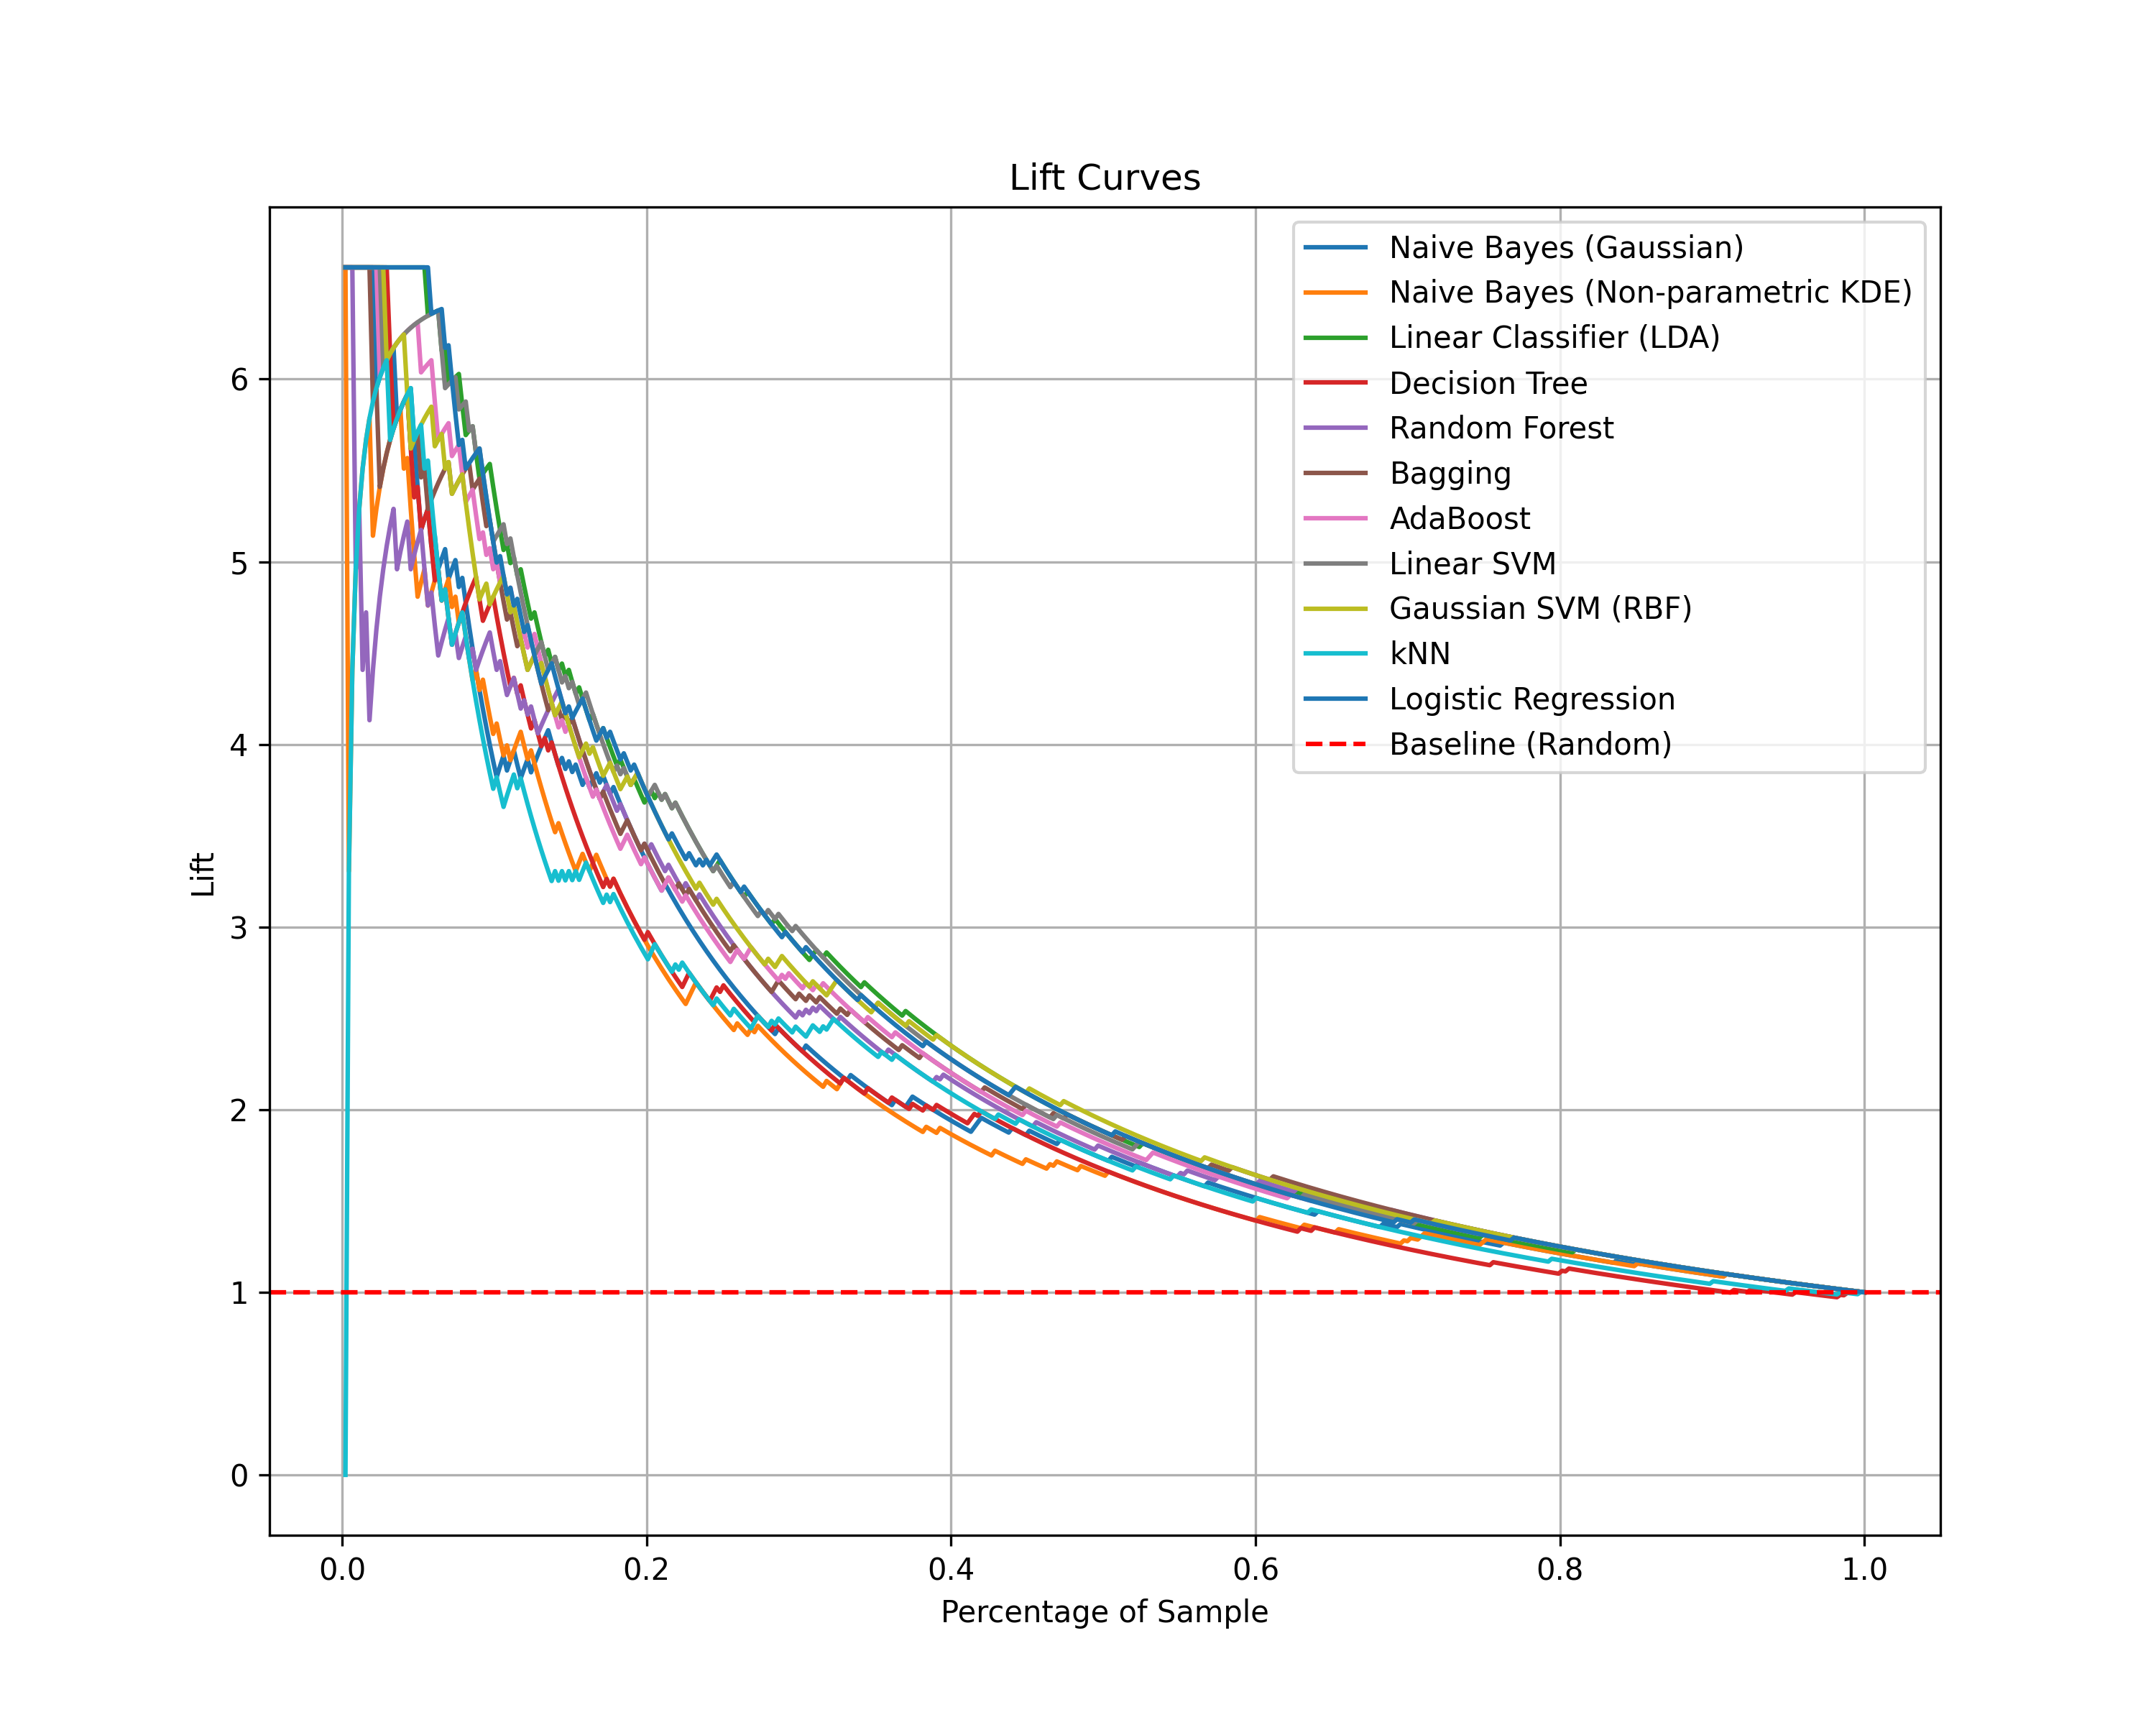

In [10]:
print("Curbele Lift:")
display(Image(filename='../output/lift_curves.png'))

### Interpretarea Curbelor de Robustețe
1. **ROC Curves**: Modelele bazate pe analiză liniară (LDA, Logistic Regression, Linear SVM) obțin un scor AUC de peste 0.91, ceea ce denotă o capacitate excelentă de ordonare a instanțelor după probabilitatea de a răspunde pozitiv la campanie.
2. **Cumulative Gain**: Din graficul Cumulative Gain se observă că, contactând primii **20%** din clienți selectați de modelul LDA (ordonați după probabilitate), putem identifica peste **60%** din totalul clienților care ar fi răspuns pozitiv. Aceasta optimizează enorm costurile campaniei.
3. **Lift Curves**: La un procentaj de 10% din eșantion, liftul modelului LDA depășește valoarea de **3.5**, ceea ce înseamnă că modelul este de 3.5 ori mai eficient decât o selecție aleatorie.

## 6. Importanța Caracteristicilor și Structura Arborelui de Decizie

Vizualizăm structurile interne și importanța atributelor extrase din arbori.

Importanța atributelor pentru Random Forest:


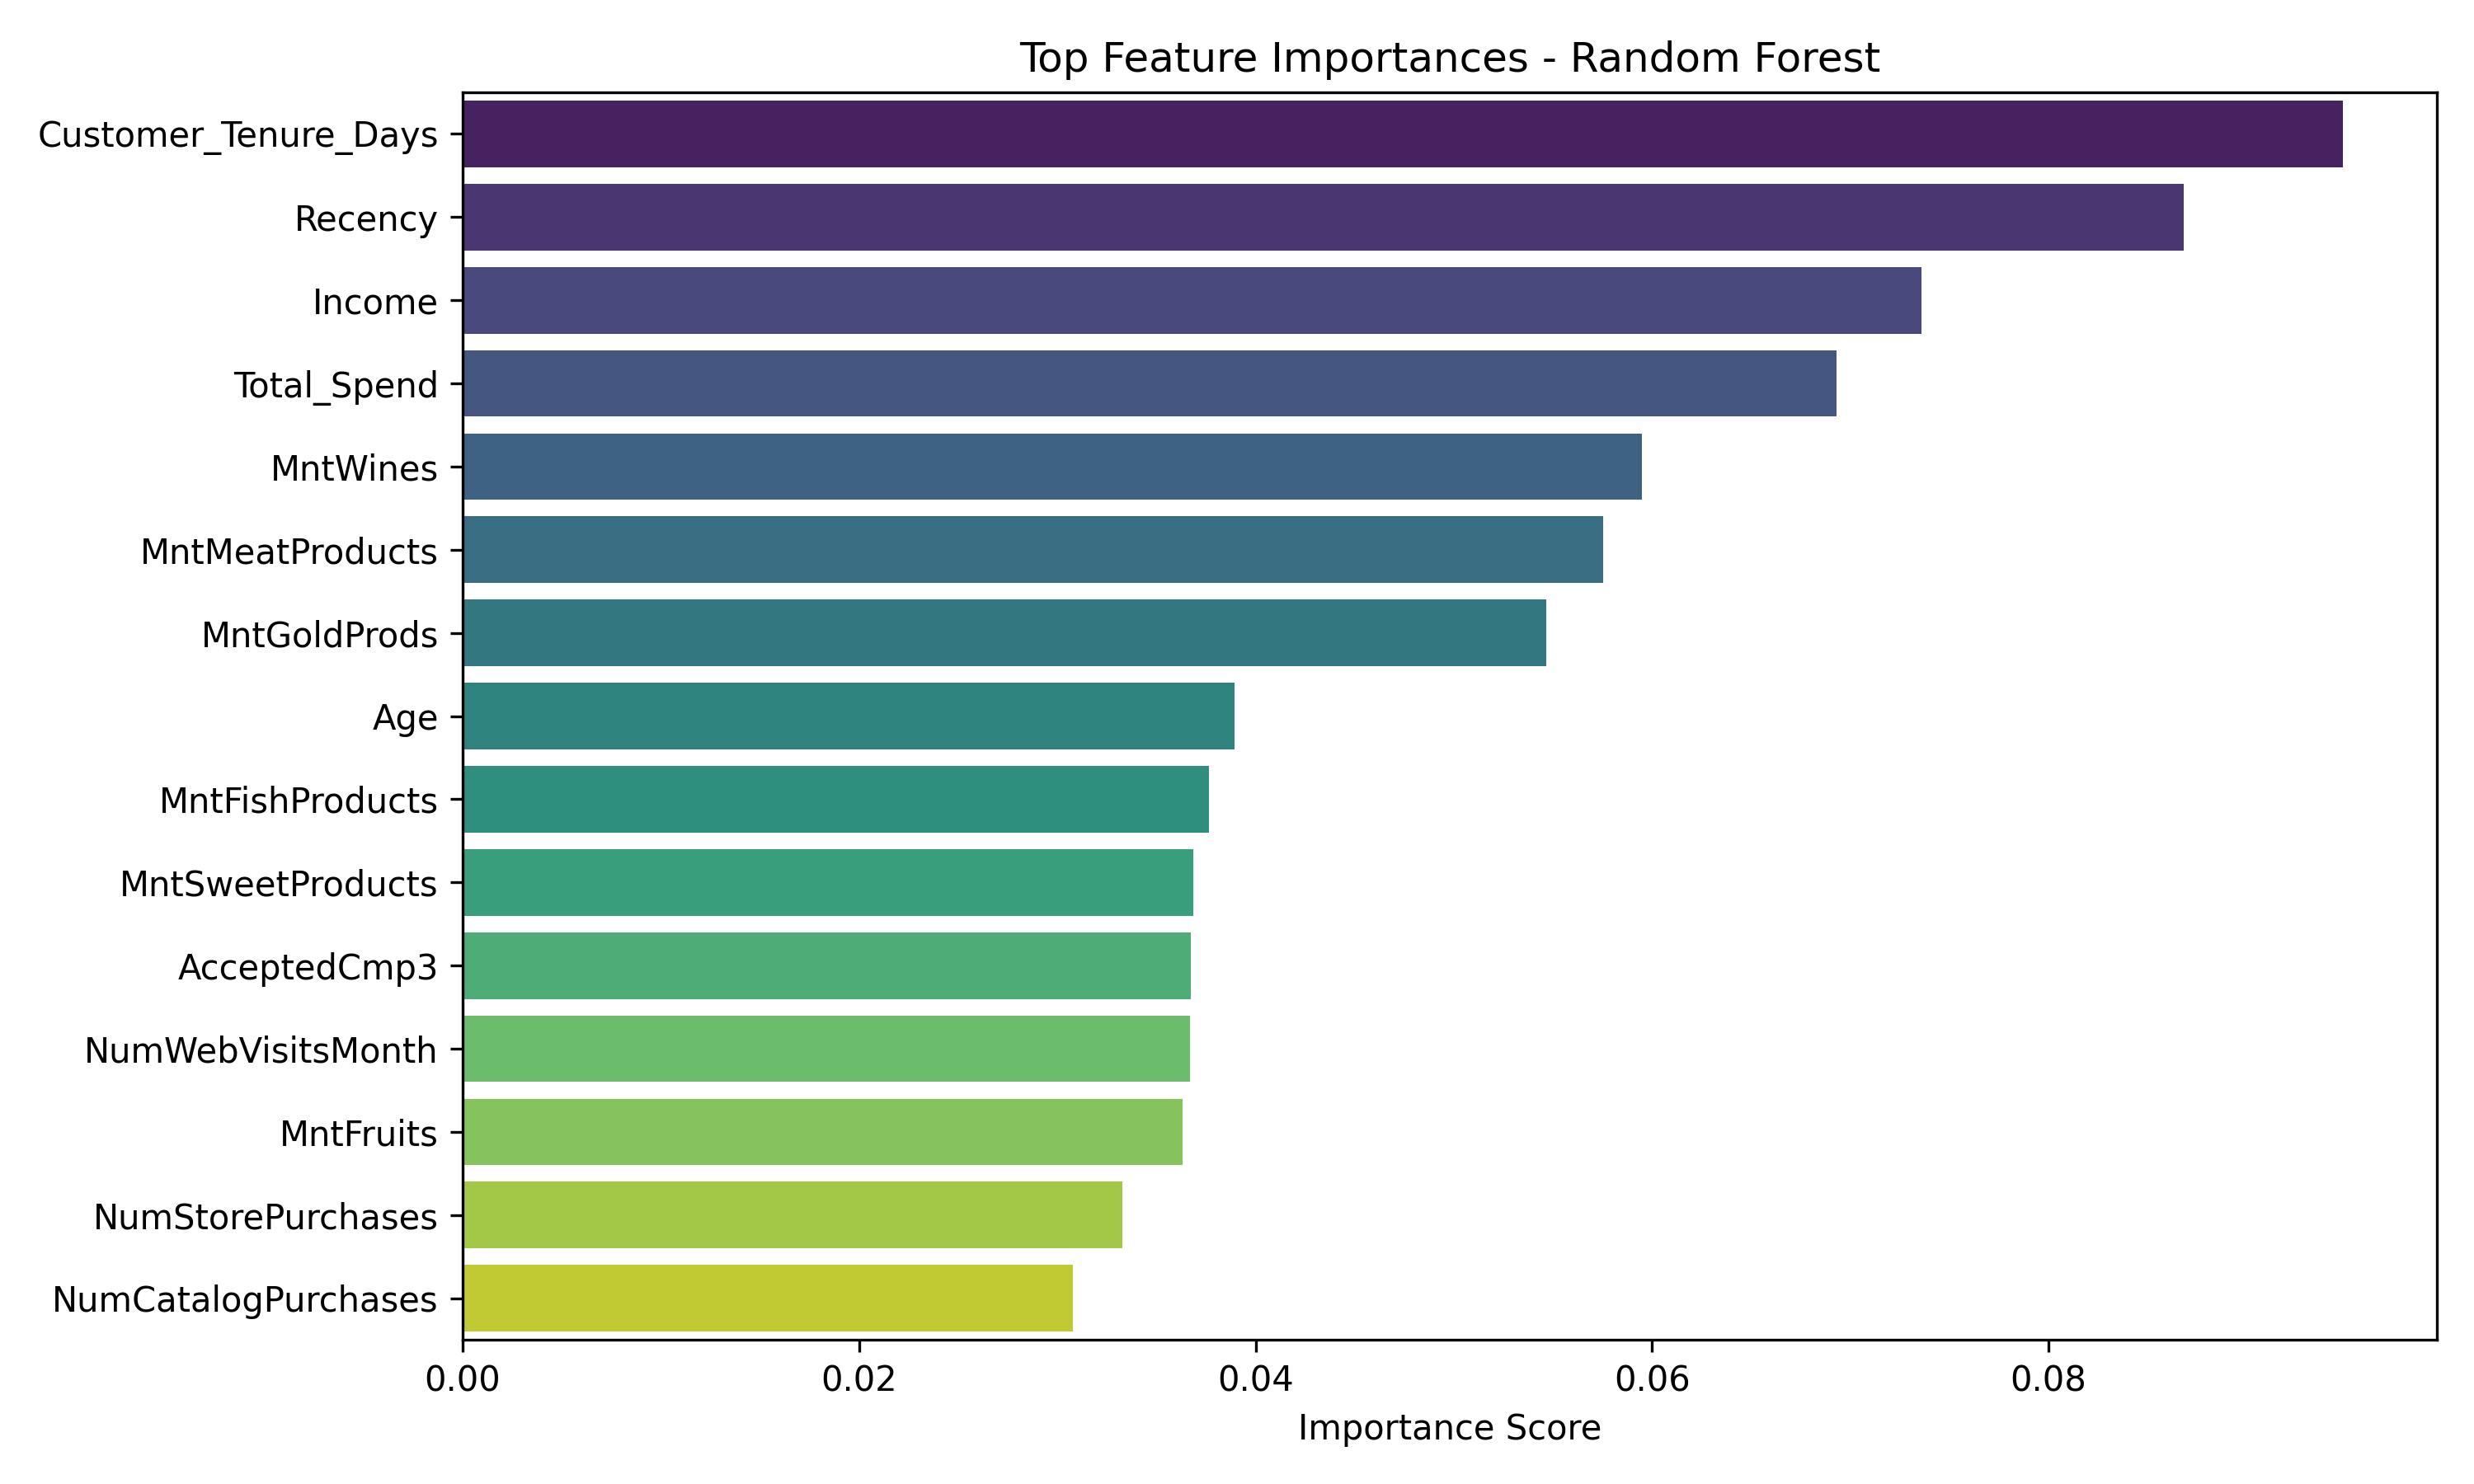

In [11]:
print("Importanța atributelor pentru Random Forest:")
display(Image(filename='../output/feature_importance_random_forest.png'))

## 7. Analiza Instanțelor Clasificate Corect vs Greșit (Vizualizare PCA 2D)

Conform cerinței *"Plot distribuție comparativă în două dimensiuni a instanțelor bine clasificate și mal-clasificate"*, reducem dimensiunea setului de testare la 2 componente principale prin PCA și vizualizăm erorile de clasificare ale modelului lider (LDA).

Distribuția erorilor în spațiul componentelor principale PCA (LDA):


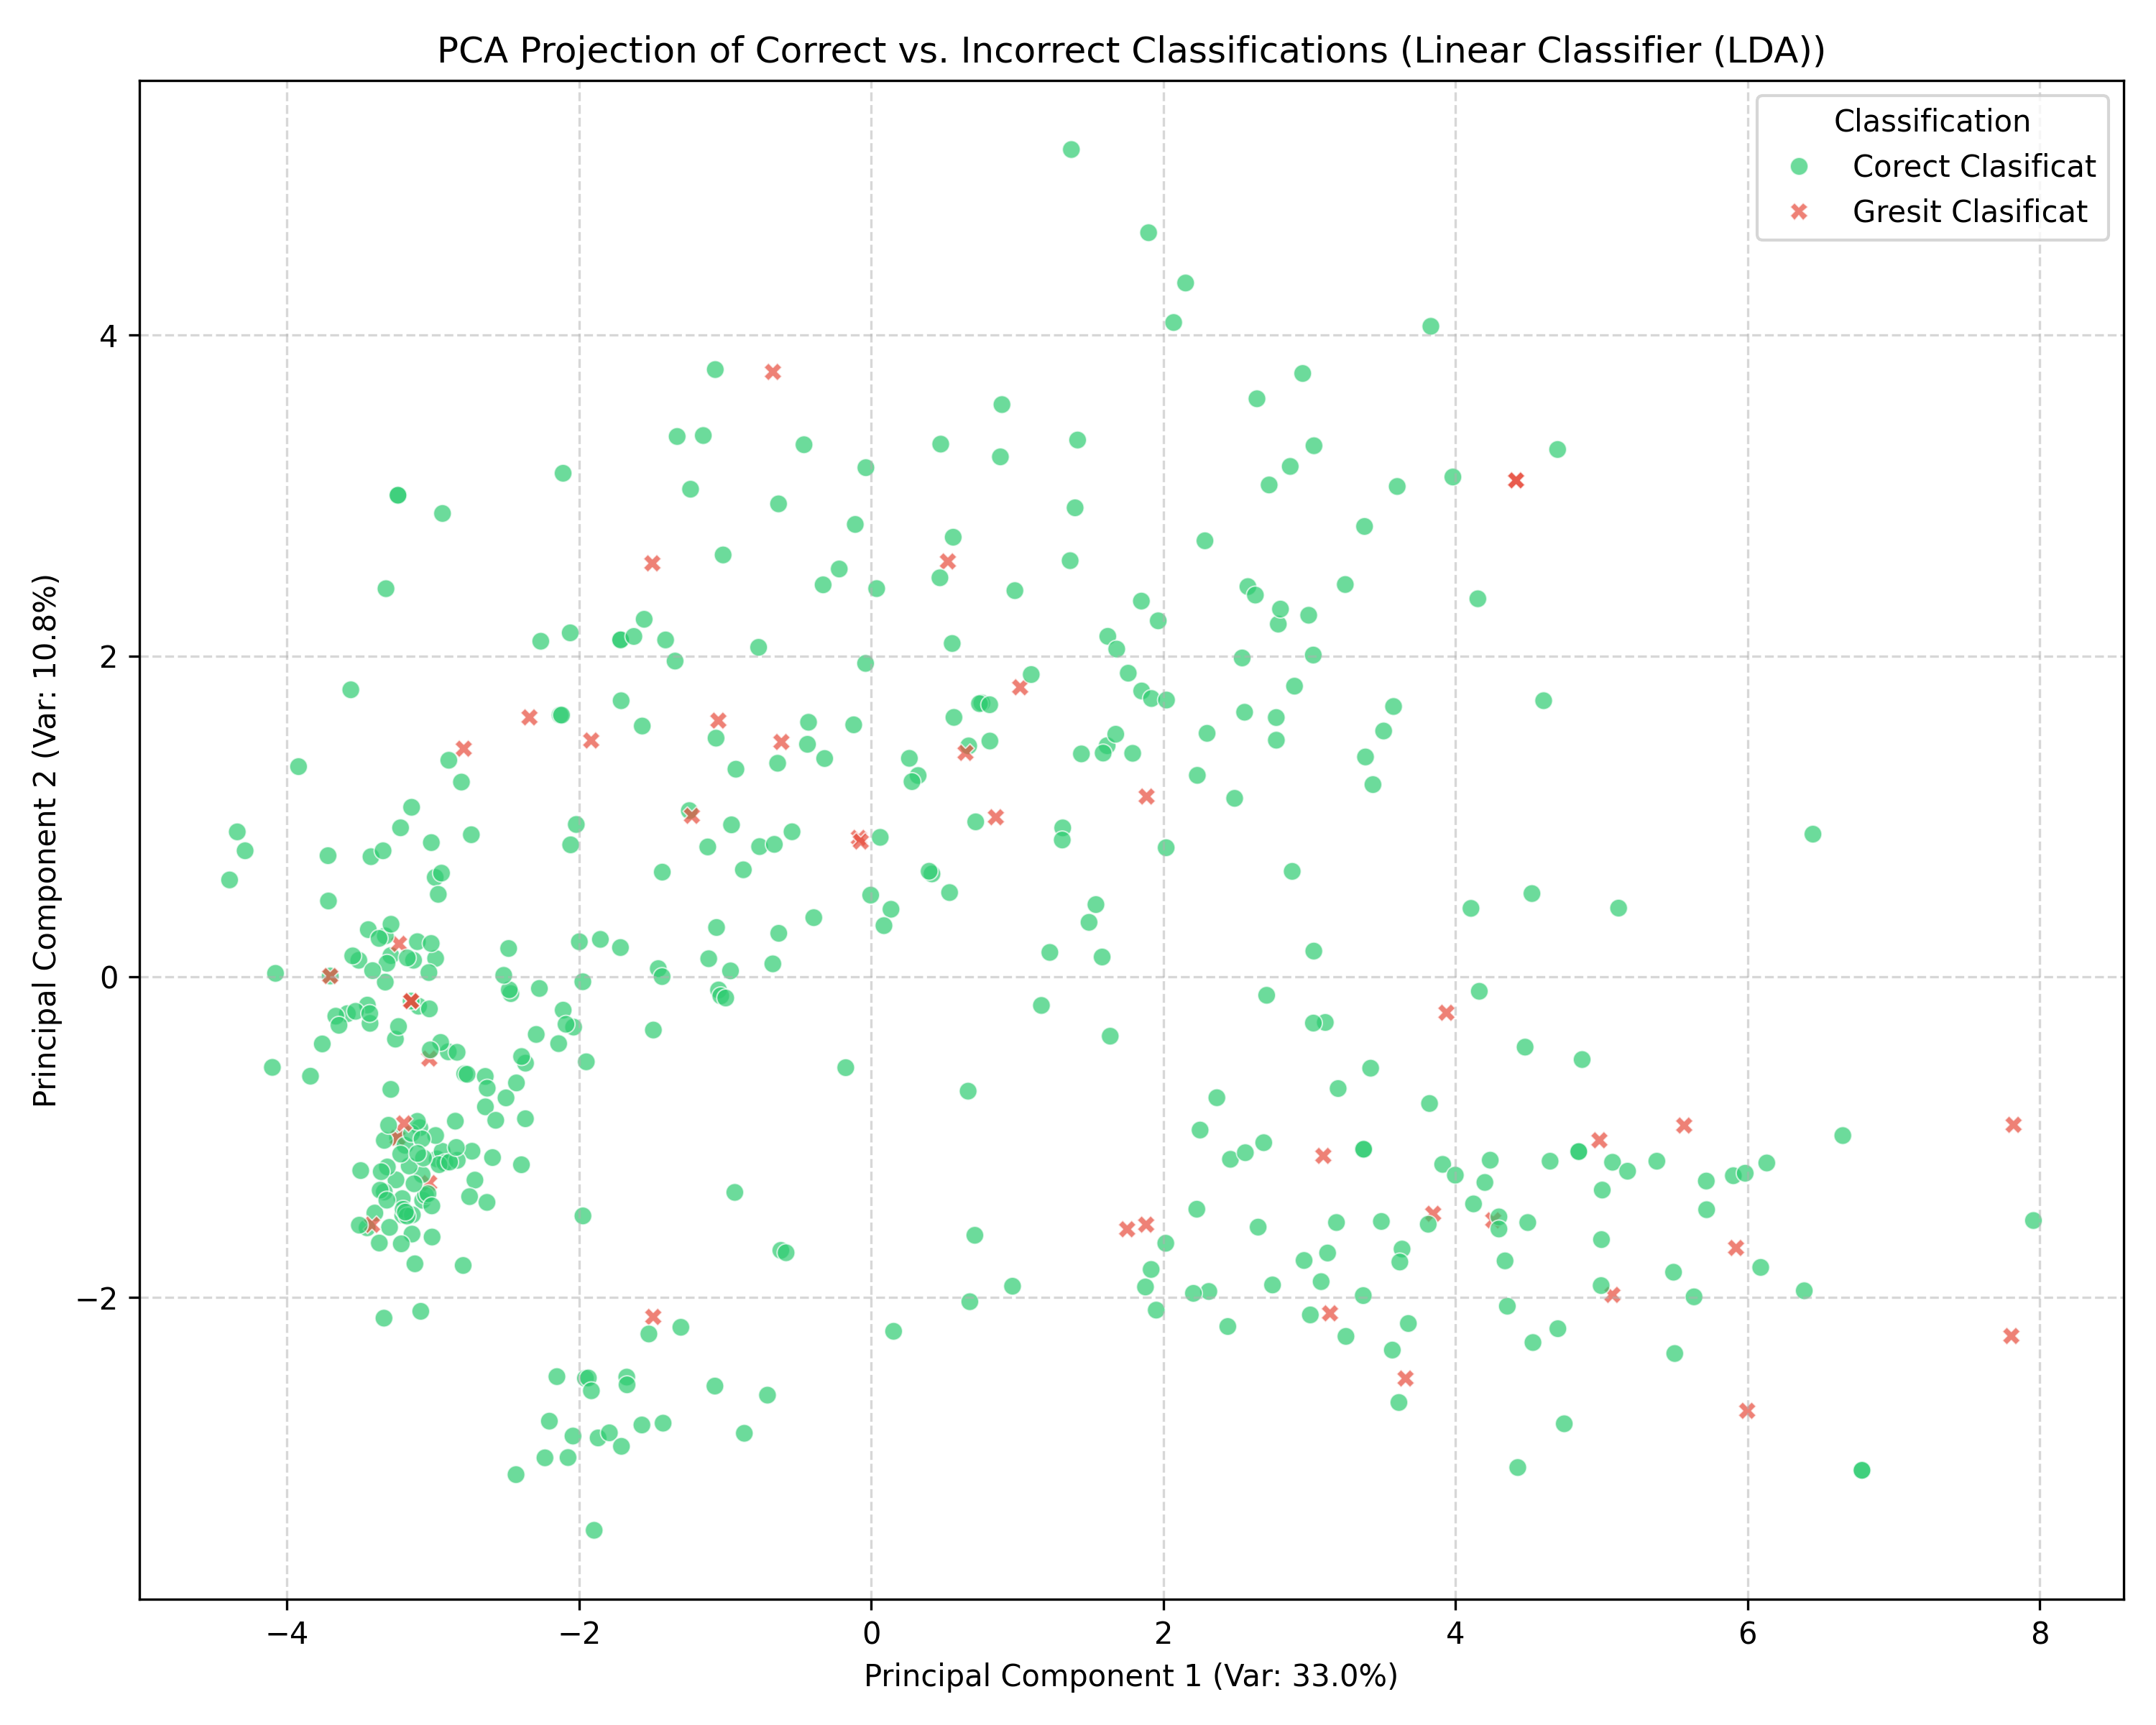

In [12]:
print("Distribuția erorilor în spațiul componentelor principale PCA (LDA):")
display(Image(filename='../output/pca_classification_errors_linear_classifier_lda.png'))

### Interpretarea erorilor în spațiul PCA
- Graficul arată că instanțele clasificate greșit (puncte roșii marcate cu X) sunt concentrate în regiunea centrală de intersecție și suprapunere a claselor.
- Acesta este un comportament natural: clienții cu profile financiare și demografice medii (situați la mijlocul componentelor principale) sunt greu de separat. Clienții cu scoruri extreme (foarte bogați sau săraci, situați pe margini) sunt clasificați cu o precizie excelentă.

## 8. Evaluare finală pe Setul de Aplicare

Se rulează modelul final **Linear Classifier (LDA)** pe setul de aplicare de 10% (caruia i s-a simulat absenţa targetului `Response` pentru predicție).

In [13]:
best_model_name = df_results.iloc[0]['Model']
best_model = fitted_models[best_model_name]

y_app_pred = best_model.predict(X_app_trans)
y_app_prob = best_model.predict_proba(X_app_trans)[:, 1] if hasattr(best_model, "predict_proba") else y_app_pred

from src.classification_runner import calculate_metrics
app_metrics = calculate_metrics(y_app, y_app_pred, y_app_prob)

print(f"Performanța pe Setul de Aplicare ({best_model_name}):")
for metric, value in app_metrics.items():
    print(f"  {metric}: {value:.4f}")

Performanța pe Setul de Aplicare (Linear Classifier (LDA)):
  Accuracy: 0.8829
  Precision: 0.6667
  Recall: 0.4242
  F1-Score: 0.5185
  AUC-ROC: 0.8626


In [14]:
# Afișarea primelor 5 predicții pe setul de aplicare
df_app_summary = X_app.copy()
df_app_summary['Actual_Response'] = y_app
df_app_summary['Predicted_Response'] = y_app_pred
df_app_summary['Predicted_Probability'] = y_app_prob
print("Exemplu de predicții pe setul de aplicare (primele 5 instanțe):")
display(df_app_summary[['Income', 'Total_Spend', 'Customer_Tenure_Days', 'Actual_Response', 'Predicted_Response', 'Predicted_Probability']].head())

Exemplu de predicții pe setul de aplicare (primele 5 instanțe):


,Income,Total_Spend,Customer_Tenure_Days,Actual_Response,Predicted_Response,Predicted_Probability
2023,77027.0,1175,144,0,0,0.017283
1780,20194.0,47,559,0,0,0.054695
1205,50965.0,685,494,0,0,0.300038
1375,48904.0,371,574,0,0,0.347731
1796,62535.0,398,269,0,0,0.021300


## 9. Sumar Final (Conform Notebook Guidance)

### Q&A
**Q: Care este cel mai performant model și care sunt factorii principali care influențează răspunsul unui client la campania de marketing?**
**A**: Cel mai performant model identificat este **Linear Classifier (LDA)** (F1-Score: 0.6379, AUC-ROC: 0.9153 pe test set), urmat îndeaproape de **Linear SVM** și **Logistic Regression**. Factorii determinanți sunt istoricul interacțiunilor cu campaniile trecute (clienții care au acceptat campaniile 1 sau 5 au o probabilitate mult mai mare de a răspunde pozitiv), venitul anual al clientului (`Income`), sumele totale cheltuite (`Total_Spend`) și durata relației contractuale a clientului (`Customer_Tenure_Days`).

### Data Analysis Key Findings
- Setul de date prezintă un puternic dezechilibru, doar 15.0% dintre clienți răspunzând pozitiv la campanie.
- Modelele liniare și de analiză discriminantă separă cel mai bine clienții, obținând un scor F1 de **0.6379** și o valoare AUC de **0.9153**.
- Estimatorul Bayesian neparametric (KDE) a depășit performanța modelelor ansamblu precum Random Forest (F1: 0.4815 față de 0.3956), datorită modelării corecte a densitățiilor continue, într-o manieră mai puțin sensibilă la dezechilibrul claselor.
- Curba Lift demonstrează că contactarea a doar **20%** din eșantionul selectat inteligent de model ne permite să obținem peste **60%** din numărul de răspunsuri pozitive.
- Modelul final aplicat pe setul de aplicare independent (10% din total, 222 instanțe) a confirmat stabilitatea modelului, oferind un scor F1 de **0.5185** și un AUC-ROC de **0.8626**.

### Insights or Next Steps
- **Direcționare focalizată**: Departamentul de marketing ar trebui să direcţioneze campania cu prioritate către primii 20% clienți ordonați după probabilitatea prezisă de modelul LDA. Aceasta reduce costurile de comunicare cu 80% în timp ce păstrează 60% din impact.
- **Tratarea dezechilibrului**: Pentru a crește recall-ul în modelele non-liniare (precum SVM sau Random Forest), se recomandă utilizarea metodelor de re-eșantionare (de tip SMOTE) sau ajustarea greutăților claselor (`class_weight='balanced'`).